In [15]:
# ── LƯU MÔ HÌNH TỐT NHẤT ──────────────────────────────
import joblib

# Lưu LinearSVC (tốt nhất)
joblib.dump(results['LinearSVC']['model'], '../models/linearsvc_model.pkl')
joblib.dump(tfidf_vectorizer, '../models/tfidf_vectorizer.pkl')

print(" Đã lưu model vào thư mục models/")

# ── BẢNG TỔNG KẾT CUỐI CÙNG ──────────────────────────
print("\n" + "="*55)
print("       BẢNG TỔNG KẾT KẾT QUẢ DỰ ÁN")
print("="*55)
print(f"{'Mô hình':<25} {'Accuracy':>10} {'F1 Macro':>10}")
print("-"*55)
for _, row in results_df.iterrows():
    print(f"{row['Mô hình']:<25} {row['Accuracy']:>10.4f} {row['F1 Macro']:>10.4f}")
print("-"*55)
print(f"\n Mô hình tốt nhất: LinearSVC")
print(f"   Sau GridSearch LR: F1=0.8517")
print(f"\n Dự án hoàn thành!")

 Đã lưu model vào thư mục models/

       BẢNG TỔNG KẾT KẾT QUẢ DỰ ÁN
Mô hình                     Accuracy   F1 Macro
-------------------------------------------------------
LinearSVC                     0.8257     0.8577
Logistic Regression           0.8308     0.8483
Random Forest                 0.8063     0.8321
Naive Bayes                   0.8193     0.7562
-------------------------------------------------------

 Mô hình tốt nhất: LinearSVC
   Sau GridSearch LR: F1=0.8517

 Dự án hoàn thành!


In [14]:
# ── E1: GridSearchCV tối ưu hóa ───────────────────
from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("=== TỐI ƯU HÓA VỚI GRIDSEARCHCV ===\n")

# ── Tối ưu Logistic Regression ──────────────────────
param_grid_lr = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'saga']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(" Đang tìm tham số tốt nhất cho Logistic Regression...")
gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid_lr,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
gs_lr.fit(X_train_tfidf, y_train)

print(f"\n Best params LR : {gs_lr.best_params_}")
print(f" Best F1 (CV)   : {gs_lr.best_score_:.4f}")

# Đánh giá trên test
y_pred_lr = gs_lr.predict(X_test_tfidf)
f1_lr = f1_score(y_test, y_pred_lr, average='macro')
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f" Test Accuracy  : {acc_lr:.4f}")
print(f" Test F1 Macro  : {f1_lr:.4f}")

=== TỐI ƯU HÓA VỚI GRIDSEARCHCV ===

 Đang tìm tham số tốt nhất cho Logistic Regression...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

 Best params LR : {'C': 10, 'solver': 'saga'}
 Best F1 (CV)   : 0.8527
 Test Accuracy  : 0.8205
 Test F1 Macro  : 0.8517


### Nhận xét — Câu D3: Phân tích mẫu dự đoán sai

**Tỉ lệ sai:** 17.4% (952/5,461 mẫu)

**Đặc điểm chung của mẫu sai:**
1. **Nhãn gần nghĩa:** ButViet ↔ DungCuHocSinh ↔ SanPhamVeGiay
   → Bút chì, bút màu xuất hiện ở cả 3 danh mục, từ vựng chồng lấp
2. **Văn bản ngắn, ít đặc trưng:** Các đánh giá ngắn như
   "tốt", "giao hàng nhanh" không có từ đặc trưng danh mục
3. **FileHoSoBiaHoSo** có F1 thấp nhất (0.129) vì số mẫu
   quá ít (87 mẫu) so với TrangDiem (1,830 mẫu)

**Đề xuất cải tiến:**
- Thêm stopwords tiếng Việt chuyên biệt
- Gộp nhãn gần nghĩa (ButViet + DungCuHocSinh)
- Thu thập thêm data cho nhãn thiểu số (FileHoSoBiaHoSo)

In [13]:
# ──  D3: Phân tích mẫu dự đoán sai ─────────────────
# Dùng LinearSVC (mô hình tốt nhất)
best_model = results['LinearSVC']['model']
y_pred_test = best_model.predict(X_test_tfidf)

# Lấy các mẫu dự đoán sai
wrong_idx = [i for i, (true, pred) in 
             enumerate(zip(y_test, y_pred_test)) if true != pred]

print(f"Tổng số mẫu sai: {len(wrong_idx):,} / {len(y_test):,}")
print(f"Tỉ lệ sai: {len(wrong_idx)/len(y_test)*100:.1f}%\n")

# Hiển thị 10 mẫu sai đầu tiên
X_test_list = X_test.tolist()
y_test_list = y_test.tolist()

print("=== 10 MẪU DỰ ĐOÁN SAI ===\n")
for i, idx in enumerate(wrong_idx[:10]):
    print(f"[{i+1}] Thực tế : {y_test_list[idx]}")
    print(f"    Dự đoán : {y_pred_test[idx]}")
    print(f"    Văn bản : {X_test_list[idx][:100]}...")
    print()

Tổng số mẫu sai: 952 / 5,461
Tỉ lệ sai: 17.4%

=== 10 MẪU DỰ ĐOÁN SAI ===

[1] Thực tế : ButViet
    Dự đoán : DungCuHocSinh
    Văn bản : butchiedu primethanxanh trương thủy tiên tốt false tháng trước bút_chì edu prime thân xanh này mình ...

[2] Thực tế : SanPhamVeGiay
    Dự đoán : DungCuHocSinh
    Văn bản : taphocsinhtikilantoaniemvui trangloc cuon trần thị thủy tốt false tháng trước một bộ cuốn mà có tới ...

[3] Thực tế : DungCuHocSinh
    Dự đoán : ButViet
    Văn bản : caychimaunuochopgiay nguyễn phương trinh tiện true tháng trước sự kết_hợp giữa màu chì và màu_nước n...

[4] Thực tế : DungCuHocSinh
    Dự đoán : SanPhamVeGiay
    Văn bản : taphocsinhtikilantoaniemvui trangloc cuon hoàng vy phù hợp tiêu chí học sinh true tháng trước mình c...

[5] Thực tế : SanPhamVeGiay
    Dự đoán : DungCuHocSinh
    Văn bản : tapsinhvientikilantoaniemvuibenthanhmarket trang lê thị thu quỳnh rất tốt true tháng trước thật_sự m...

[6] Thực tế : DungCuHocSinh
    Dự đoán : SanPhamVeGiay
    Vă

In [12]:
# ── D1: Đánh giá trên tập Test ────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

print("=== KẾT QUẢ TRÊN TẬP TEST ===\n")

summary = []
for name, res in results.items():
    model = res['model']
    if name == 'Random Forest':
        X_te = rf_vec.transform(X_test)
    else:
        X_te = X_test_tfidf
    
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    prec = f1_score(y_test, y_pred, average='macro',
                    labels=y_test.unique())
    
    summary.append({
        'Mô hình'  : name,
        'Accuracy' : round(acc, 4),
        'F1 Macro' : round(f1, 4),
    })
    print(f"{'─'*50}")
    print(f" {name}")
    print(classification_report(y_test, y_pred, digits=3))

# Bảng tổng hợp
results_df = pd.DataFrame(summary)
results_df = results_df.sort_values('F1 Macro', ascending=False)
print("\n=== BẢNG TỔNG HỢP ===")
print(results_df.to_string(index=False))

=== KẾT QUẢ TRÊN TẬP TEST ===

──────────────────────────────────────────────────
 Naive Bayes
                             precision    recall  f1-score   support

                    ButViet      0.596     0.566     0.580       479
                     DauGoi      1.000     0.818     0.900       170
               DoDungNhaBep      0.960     0.962     0.961       444
                Dodungchobe      1.000     0.771     0.871       293
              DungCuHocSinh      0.557     0.409     0.472       802
            FileHoSoBiaHoSo      1.000     0.069     0.129        87
PhuKienDienThoaiMayTinhBang      0.983     0.900     0.940       251
              SanPhamVeGiay      0.680     0.916     0.781       783
                    TaiNghe      0.994     0.963     0.978       322
                  TrangDiem      0.910     0.997     0.951      1830

                   accuracy                          0.819      5461
                  macro avg      0.868     0.737     0.756      5461
      

In [11]:
# ── C2: Train 4 mô hình ────────────────────────────
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import time

models = {
    'Naive Bayes'         : MultinomialNB(alpha=1.0),
    'Logistic Regression' : LogisticRegression(C=1, max_iter=1000, random_state=RANDOM_STATE),
    'LinearSVC'           : LinearSVC(C=1, random_state=RANDOM_STATE, max_iter=2000),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
}

results = {}
print("=== HUẤN LUYỆN CÁC MÔ HÌNH ===\n")

for name, model in models.items():
    start = time.time()
    
    # Train
    if name == 'Random Forest':
        from sklearn.feature_extraction.text import TfidfVectorizer
        rf_vec = TfidfVectorizer(max_features=5000, ngram_range=(1,1), sublinear_tf=True)
        X_tr = rf_vec.fit_transform(X_train)
        X_v  = rf_vec.transform(X_val)
        model.fit(X_tr, y_train)
        y_pred_val = model.predict(X_v)
    else:
        model.fit(X_train_tfidf, y_train)
        y_pred_val = model.predict(X_val_tfidf)
    
    elapsed = time.time() - start
    acc = accuracy_score(y_val, y_pred_val)
    f1  = f1_score(y_val, y_pred_val, average='macro')
    
    results[name] = {'model': model, 'acc': acc, 'f1': f1}
    print(f" {name:25s} | Acc: {acc:.4f} | F1: {f1:.4f} | {elapsed:.1f}s")

print("\n Mô hình tốt nhất trên Val set:")
best = max(results, key=lambda k: results[k]['f1'])
print(f"   → {best} (F1={results[best]['f1']:.4f})")

=== HUẤN LUYỆN CÁC MÔ HÌNH ===

 Naive Bayes               | Acc: 0.8125 | F1: 0.7595 | 0.0s
 Logistic Regression       | Acc: 0.8264 | F1: 0.8440 | 3.3s
 LinearSVC                 | Acc: 0.8290 | F1: 0.8573 | 3.3s
 Random Forest             | Acc: 0.8063 | F1: 0.8291 | 128.2s

 Mô hình tốt nhất trên Val set:
   → LinearSVC (F1=0.8573)


In [ ]:
# ── C1: Train/Val/Test Split ───────────────────────
from sklearn.model_selection import train_test_split

X = df['clean_text'].fillna('')
y = df['label']

# Split 70% train, 10% val, 20% test — dùng stratify giữ tỉ lệ nhãn
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=RANDOM_STATE, stratify=y_train
)

print("=== PHÂN CHIA DỮ LIỆU ===")
print(f"Train : {len(X_train):,} mẫu ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val   : {len(X_val):,} mẫu ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test  : {len(X_test):,} mẫu ({len(X_test)/len(X)*100:.1f}%)")

print("\n--- Phân phối nhãn trong tập Train ---")
print(y_train.value_counts())

# Vectorize bằng TF-IDF — fit trên train, transform trên val/test
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf   = tfidf_vectorizer.transform(X_val)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(f"\n Shape TF-IDF train: {X_train_tfidf.shape}")
print("  Chú ý: fit_transform chỉ dùng trên TRAIN, transform trên val/test!")

=== PHÂN CHIA DỮ LIỆU ===
Train : 19,112 mẫu (70.0%)
Val   : 2,731 mẫu (10.0%)
Test  : 5,461 mẫu (20.0%)

--- Phân phối nhãn trong tập Train ---
label
TrangDiem                      6405
DungCuHocSinh                  2805
SanPhamVeGiay                  2738
ButViet                        1676
DoDungNhaBep                   1556
TaiNghe                        1129
Dodungchobe                    1026
PhuKienDienThoaiMayTinhBang     879
DauGoi                          593
FileHoSoBiaHoSo                 305
Name: count, dtype: int64

 Shape TF-IDF train: (19112, 10000)
  Chú ý: fit_transform chỉ dùng trên TRAIN, transform trên val/test!


### Giải thích — Câu A4: BoW vs TF-IDF

**Bag of Words (BoW):**
- Đếm số lần xuất hiện của từng từ trong văn bản
- Ưu điểm: Đơn giản, nhanh
- Nhược điểm: Từ phổ biến ("mình", "rất", "không") 
  có tần suất cao nhưng không phân biệt danh mục

**TF-IDF (Term Frequency - Inverse Document Frequency):**
- TF: tần suất từ trong văn bản
- IDF: nghịch đảo tần suất trong toàn bộ corpus
- Từ xuất hiện nhiều ở MỌI văn bản → IDF thấp → trọng số thấp
- Từ đặc trưng cho 1 danh mục → IDF cao → trọng số cao
- `sublinear_tf=True`: dùng log(TF) thay vì TF thô → giảm ảnh hưởng từ lặp nhiều

**Kết luận:** TF-IDF phù hợp hơn BoW cho bài toán phân loại
vì nó làm nổi bật từ đặc trưng của từng danh mục sản phẩm.

In [9]:
# ── A4: Feature Extraction - BoW và TF-IDF ─────────
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Lấy cột clean_text đã xử lý
texts = df['clean_text'].fillna('')

# ── Bag of Words ──────────────────────────────────────
bow_vectorizer = CountVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)
X_bow = bow_vectorizer.fit_transform(texts)

print("=== BAG OF WORDS ===")
print(f"Shape ma trận : {X_bow.shape}")
print(f"Số features   : {X_bow.shape[1]:,}")
print(f"Top 10 từ phổ biến nhất:")
vocab_bow = bow_vectorizer.get_feature_names_out()
freq = X_bow.sum(axis=0).A1
top10_idx = freq.argsort()[::-1][:10]
for i in top10_idx:
    print(f"  '{vocab_bow[i]}': {int(freq[i]):,} lần")

# ── TF-IDF ────────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)
X_tfidf = tfidf_vectorizer.fit_transform(texts)

print("\n=== TF-IDF ===")
print(f"Shape ma trận : {X_tfidf.shape}")
print(f"Số features   : {X_tfidf.shape[1]:,}")
print(f"\nTop 10 từ có TF-IDF cao nhất:")
tfidf_mean = X_tfidf.mean(axis=0).A1
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()
top10_tfidf = tfidf_mean.argsort()[::-1][:10]
for i in top10_tfidf:
    print(f"  '{vocab_tfidf[i]}': {tfidf_mean[i]:.4f}")

print("\n Hoàn thành feature extraction!")

=== BAG OF WORDS ===
Shape ma trận : (27304, 10000)
Số features   : 10,000
Top 10 từ phổ biến nhất:
  'mình': 48,095 lần
  'rất': 39,830 lần
  'không': 31,415 lần
  'trước': 30,126 lần
  'có': 25,408 lần
  'và': 25,153 lần
  'là': 24,504 lần
  'tháng': 24,042 lần
  'tháng trước': 23,136 lần
  'này': 22,923 lần

=== TF-IDF ===
Shape ma trận : (27304, 10000)
Số features   : 10,000

Top 10 từ có TF-IDF cao nhất:
  'mình': 0.0338
  'rất': 0.0316
  'không': 0.0270
  'và': 0.0250
  'có': 0.0249
  'là': 0.0244
  'màu': 0.0238
  'này': 0.0236
  'tốt': 0.0234
  'trước': 0.0223

 Hoàn thành feature extraction!


### Giải thích hàm preprocess_text() — Câu A3

| Bước | Xử lý | Lý do |
|------|--------|-------|
| 1 | Lowercase | "Tốt" và "tốt" cùng nghĩa → tránh đếm trùng |
| 2 | Xóa HTML tags | Không mang thông tin nội dung |
| 3 | Xóa URL | Không liên quan đến chủ đề sản phẩm |
| 4 | Xóa ký tự đặc biệt | "!!!" không mang nghĩa phân loại |
| 5 | Xóa số | Số lượng/giá tiền không đặc trưng cho danh mục |
| 6 | Xóa khoảng trắng thừa | Chuẩn hóa đầu vào |

**Nhận xét:** Dataset tiếng Việt không cần stemming/lemmatization
vì tiếng Việt là ngôn ngữ đơn lập, mỗi âm tiết đã là đơn vị nghĩa độc lập.

In [8]:
# ── A3: Hàm tiền xử lý văn bản ────────────────────
import re

def preprocess_text(text):
    # Bước 1: Chuyển lowercase
    text = str(text).lower()
    
    # Bước 2: Loại bỏ HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # Bước 3: Loại bỏ URL
    text = re.sub(r'http\S+|www\S+', ' ', text)
    
    # Bước 4: Loại bỏ ký tự đặc biệt, giữ lại chữ cái tiếng Việt
    text = re.sub(r'[^\w\sàáảãạăắặẳẵặâấầẩẫậđèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵ]', ' ', text)
    
    # Bước 5: Loại bỏ số
    text = re.sub(r'\d+', ' ', text)
    
    # Bước 6: Loại bỏ khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Test thử hàm
samples = [
    "Sản phẩm rất tốt Giao hàng nhanh 123, recommend 100%",
    "<b>Chất lượng</b> tệ, không như mô tả http://tiki.vn",
    "Bút viết trơn tru, mực đều, giá hợp lý ^^"
]

print("=== TEST HÀM PREPROCESS_TEXT ===\n")
for s in samples:
    print(f"Input : {s}")
    print(f"Output: {preprocess_text(s)}")
    print()

# Áp dụng lên toàn bộ dataset
df['clean_text'] = df['review_text'].apply(preprocess_text)
print(f" Đã xử lý {len(df):,} dòng!")
print(f"\nVí dụ trước/sau:")
print(f"Before: {df['review_text'].iloc[0][:80]}")
print(f"After : {df['clean_text'].iloc[0][:80]}")

=== TEST HÀM PREPROCESS_TEXT ===

Input : Sản phẩm rất tốt Giao hàng nhanh 123, recommend 100%
Output: sản phẩm rất tốt giao hàng nhanh recommend

Input : <b>Chất lượng</b> tệ, không như mô tả http://tiki.vn
Output: chất lượng tệ không như mô tả

Input : Bút viết trơn tru, mực đều, giá hợp lý ^^
Output: bút viết trơn tru mực đều giá hợp lý

 Đã xử lý 27,304 dòng!

Ví dụ trước/sau:
Before: ButBiSignoGelErasable05KemGomTayMucUm101Er	Ocsan Hatsunemiku	100	Tạm ổn	0	Fals
After : butbisignogelerasable kemgomtaymucum er ocsan hatsunemiku ta m ô n false tháng t


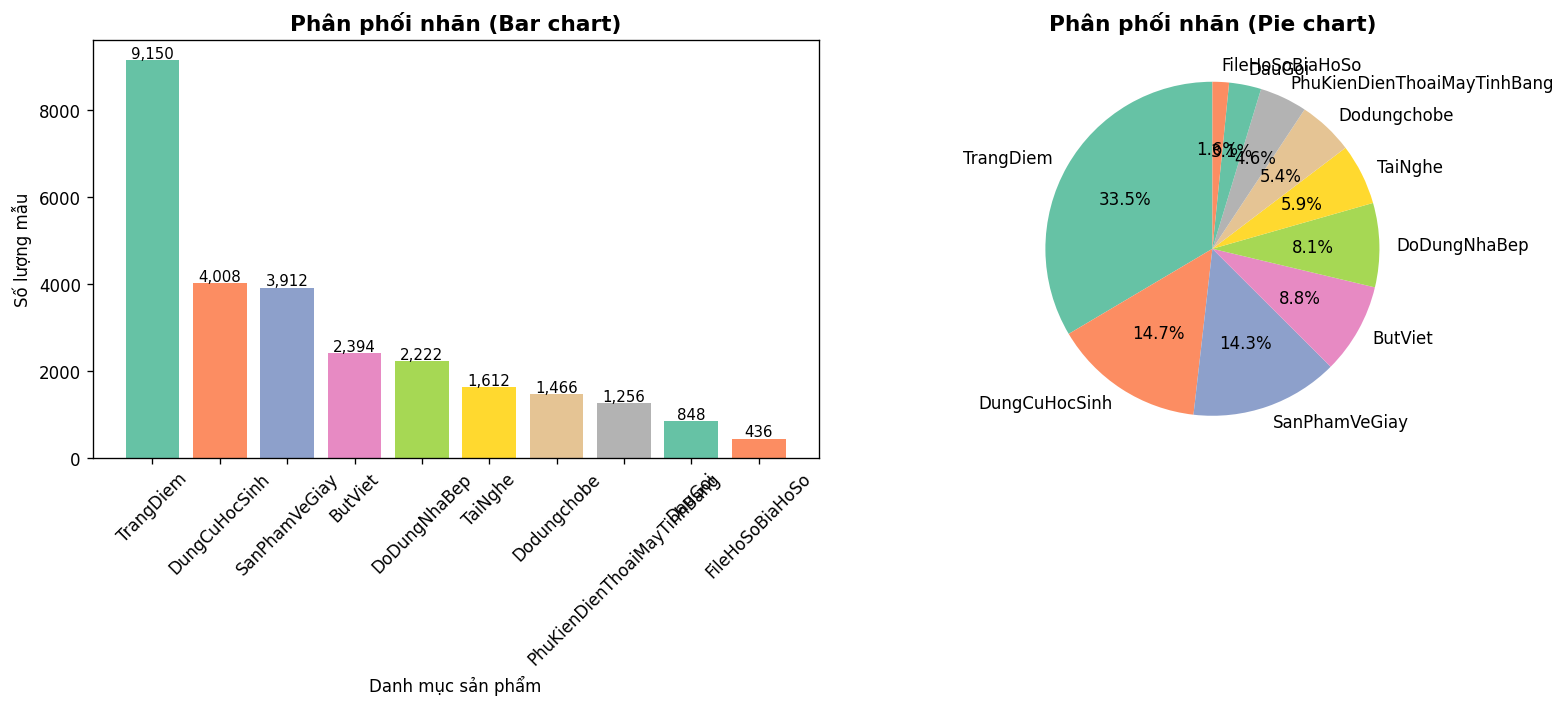

Đã lưu biểu đồ phân phối nhãn


In [7]:
# ── B1: Biểu đồ phân phối nhãn ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
label_counts = df['label'].value_counts()
colors = sns.color_palette('Set2', len(label_counts))

axes[0].bar(label_counts.index, label_counts.values, color=colors)
axes[0].set_title('Phân phối nhãn (Bar chart)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Danh mục sản phẩm')
axes[0].set_ylabel('Số lượng mẫu')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Phân phối nhãn (Pie chart)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/label_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("Đã lưu biểu đồ phân phối nhãn")

=== THỐNG KÊ ĐỘ DÀI VĂN BẢN THEO NHÃN ===

                            word_count                 char_count              \
                                  mean median min  max       mean median  min   
label                                                                           
ButViet                           83.9   76.0  49  315      398.4  365.0  242   
DauGoi                            82.9   75.0  51  198      413.4  380.0  285   
DoDungNhaBep                      83.8   78.0  49  230      411.8  383.0  266   
Dodungchobe                       84.2   78.0  52  212      409.8  383.0  277   
DungCuHocSinh                     81.2   74.0  45  314      393.9  364.0  218   
FileHoSoBiaHoSo                   80.7   73.0  51  194      391.7  360.5  270   
PhuKienDienThoaiMayTinhBang       81.0   74.0  53  234      411.6  382.0  274   
SanPhamVeGiay                     81.2   74.0  49  232      407.2  376.0  264   
TaiNghe                           87.5   79.0  49  484      425.8 

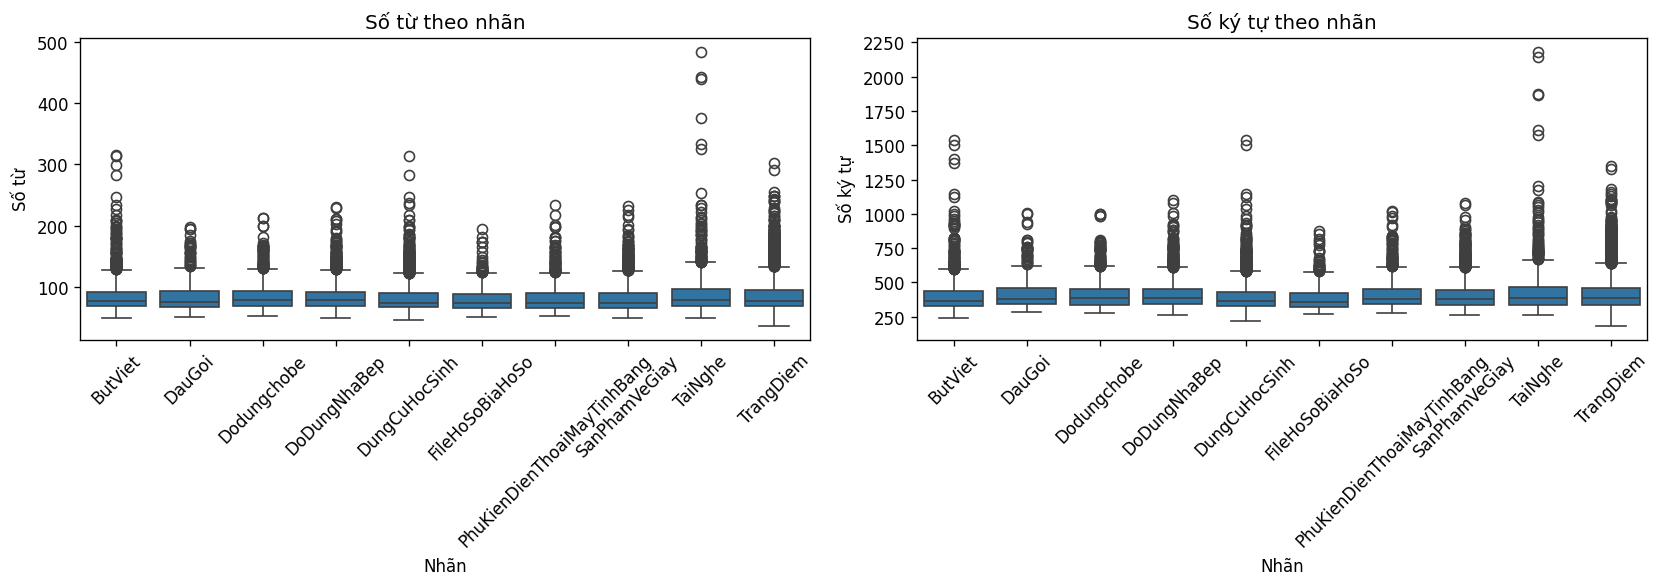

 Đã lưu biểu đồ


In [5]:
# ── A2: Thống kê độ dài văn bản ───────────────────
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['review_text'].apply(lambda x: len(str(x)))

print("=== THỐNG KÊ ĐỘ DÀI VĂN BẢN THEO NHÃN ===\n")
stats = df.groupby('label')[['word_count', 'char_count']].agg(
    ['mean', 'median', 'min', 'max']
).round(1)
print(stats)

# Vẽ biểu đồ phân phối độ dài
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='label', y='word_count', ax=axes[0])
axes[0].set_title('Số từ theo nhãn')
axes[0].set_xlabel('Nhãn')
axes[0].set_ylabel('Số từ')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='label', y='char_count', ax=axes[1])
axes[1].set_title('Số ký tự theo nhãn')
axes[1].set_xlabel('Nhãn')
axes[1].set_ylabel('Số ký tự')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/word_count_by_label.png', dpi=120, bbox_inches='tight')
plt.show()
print(" Đã lưu biểu đồ")

In [4]:
# ─ A1: Phân phối nhãn ─────────────────────────────
print("=== PHÂN PHỐI NHÃN ===")
label_counts = df['label'].value_counts()
print(label_counts)
print()

total = len(df)
for label, count in label_counts.items():
    print(f"  {label:30s}: {count:,} mẫu ({count/total*100:.1f}%)")

print()
ratio = label_counts.max() / label_counts.min()
if ratio > 1.5:
    print(f"  Dữ liệu MẤT CÂN BẰNG! Tỉ lệ max/min = {ratio:.2f}")
else:
    print(f" Dữ liệu cân bằng (tỉ lệ = {ratio:.2f})")

=== PHÂN PHỐI NHÃN ===
label
TrangDiem                      9150
DungCuHocSinh                  4008
SanPhamVeGiay                  3912
ButViet                        2394
DoDungNhaBep                   2222
TaiNghe                        1612
Dodungchobe                    1466
PhuKienDienThoaiMayTinhBang    1256
DauGoi                          848
FileHoSoBiaHoSo                 436
Name: count, dtype: int64

  TrangDiem                     : 9,150 mẫu (33.5%)
  DungCuHocSinh                 : 4,008 mẫu (14.7%)
  SanPhamVeGiay                 : 3,912 mẫu (14.3%)
  ButViet                       : 2,394 mẫu (8.8%)
  DoDungNhaBep                  : 2,222 mẫu (8.1%)
  TaiNghe                       : 1,612 mẫu (5.9%)
  Dodungchobe                   : 1,466 mẫu (5.4%)
  PhuKienDienThoaiMayTinhBang   : 1,256 mẫu (4.6%)
  DauGoi                        : 848 mẫu (3.1%)
  FileHoSoBiaHoSo               : 436 mẫu (1.6%)

  Dữ liệu MẤT CÂN BẰNG! Tỉ lệ max/min = 20.99


In [3]:
# ── A1: Load data ────────────────
df = pd.read_csv('../data/tiki_reviews.csv')

print("=== CẤU TRÚC DATAFRAME ===")
print(f"Số dòng  : {df.shape[0]:,}")
print(f"Số cột   : {df.shape[1]}")
print(f"\nTên cột  : {list(df.columns)}")
print(f"\nKiểu dữ liệu:")
print(df.dtypes)
print(f"\n--- 10 dòng đầu ---")
df.head(10)

=== CẤU TRÚC DATAFRAME ===
Số dòng  : 27,304
Số cột   : 3

Tên cột  : ['review_text', 'label', 'split']

Kiểu dữ liệu:
review_text    str
label          str
split          str
dtype: object

--- 10 dòng đầu ---


,review_text,label,split
0,ButBiSignoGelErasable05KemGomTayMucUm101Er\tOc...,ButViet,train
1,ButBiSignoGelErasable05KemGomTayMucUm101Er\tTr...,ButViet,train
2,ButBiSignoGelErasable05KemGomTayMucUm101Er\tPh...,ButViet,train
3,ButBiSignoGelErasable05KemGomTayMucUm101Er\tĐặ...,ButViet,train
4,ButBiSignoGelErasable05KemGomTayMucUm101Er\tPh...,ButViet,train
5,ButBiSignoGelErasable05KemGomTayMucUm101Er\tHồ...,ButViet,train
6,ButBiSignoGelErasable05KemGomTayMucUm101Er\tNg...,ButViet,train
7,ButBiSignoGelErasable05KemGomTayMucUm101Er\tTr...,ButViet,train
8,BoVeDaNangHieuHopGoColormate110W\tĐỗ Vân\t80\t...,ButViet,train
9,BoVeDaNangHieuHopGoColormate110W\tTrầN QuốC ...,ButViet,train


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 120

print(" Import thư viện thành công!")
print(f"pandas version: {pd.__version__}")
print(f"numpy version:  {np.__version__}")

 Import thư viện thành công!
pandas version: 3.0.3
numpy version:  2.4.6


# Phần A.1 — Khám phá dữ liệu ban đầu (EDA)
**Dataset:** Tiki Reviews — Phân loại danh mục sản phẩm  
**Mục tiêu:** Load data, mô tả cấu trúc, phân tích phân phối nhãn